# Lab IV: Linear Models - Question Set 2

### Import Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

## Car Data

This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

#####  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly skewed variables that require a log or arcsinh transformation) Note this is different than normalizing: there is a text below that explains further. Clean the data however you think is most appropriate.

In [2]:
cars = pd.read_csv("cars_hw.csv")
cars.info()

<class 'pandas.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Unnamed: 0         976 non-null    int64
 1   Make               976 non-null    str  
 2   Make_Year          976 non-null    int64
 3   Color              976 non-null    str  
 4   Body_Type          976 non-null    str  
 5   Mileage_Run        976 non-null    int64
 6   No_of_Owners       976 non-null    str  
 7   Seating_Capacity   976 non-null    int64
 8   Fuel_Type          976 non-null    str  
 9   Transmission       976 non-null    str  
 10  Transmission_Type  976 non-null    str  
 11  Price              976 non-null    int64
dtypes: int64(5), str(7)
memory usage: 91.6 KB


In [3]:
cars.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


Let's drop that "Unnamed: 0" column:

In [4]:
cars = cars.drop(columns=["Unnamed: 0"])

Right now, the No_of_Owners column is a string but it might be better as an integer:

In [5]:
# There's only 3 unique values: "1st", "2nd", or "3rd"
cars["No_of_Owners"] = cars["No_of_Owners"].map({
    "1st": 1,
    "2nd": 2,
    "3rd": 3,
})

Now for the continuous variables of Mileage_Run and Price, let's check if they're skewed:

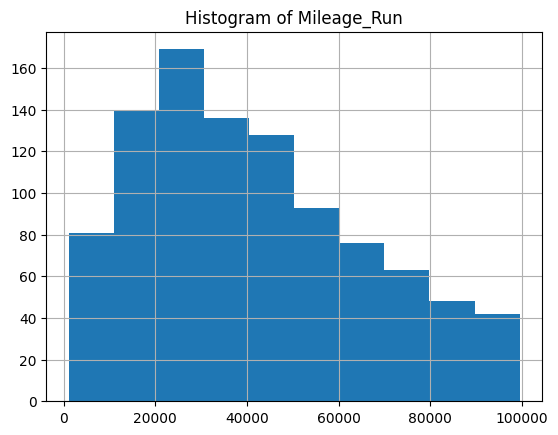

In [6]:
# Histogram
cars["Mileage_Run"].hist()
plt.title("Histogram of Mileage_Run")
plt.show()

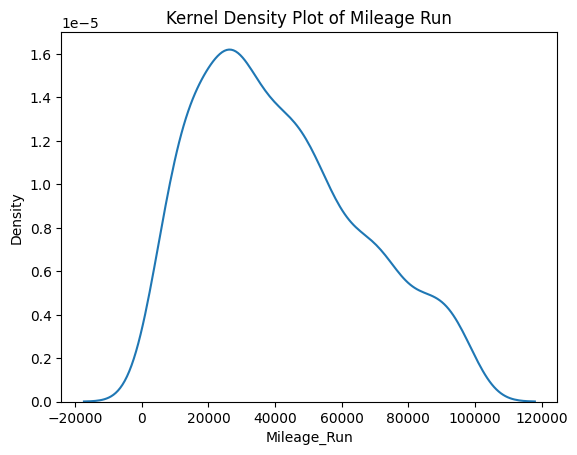

In [7]:
# kde plot
sns.kdeplot(cars, x = "Mileage_Run")
plt.title("Kernel Density Plot of Mileage Run")
plt.show()

Looks like mileage_run is slightly right skewed

Now Price:

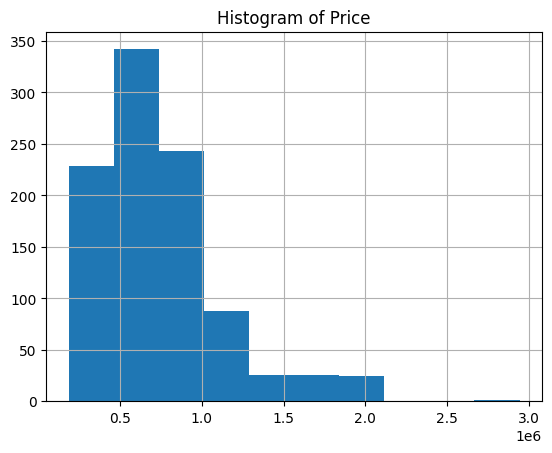

In [8]:
# Histogram
cars["Price"].hist()
plt.title("Histogram of Price")
plt.show()

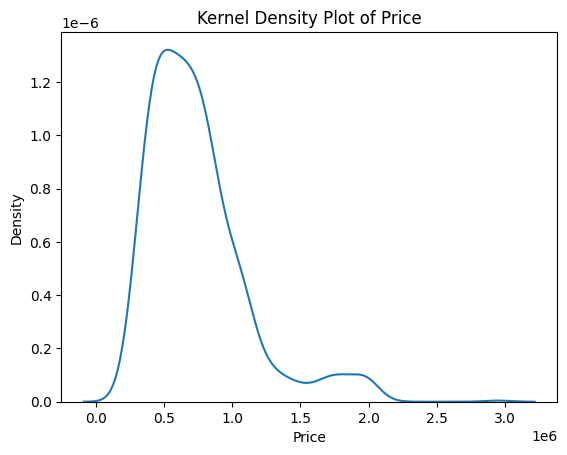

In [9]:
# kde plot
sns.kdeplot(cars, x = "Price")
plt.title("Kernel Density Plot of Price")
plt.show()

Price appears to be more right skewed.

Since both variables are strictly positive and right-skewed with large variations in magnitude, let's apply a log transformation to both Mileage_Run and Price:

In [10]:
cars["log_mileage"] = np.log(cars["Mileage_Run"])
cars["log_price"] = np.log(cars["Price"])

Now let's check for any outliers in these continuous variables:

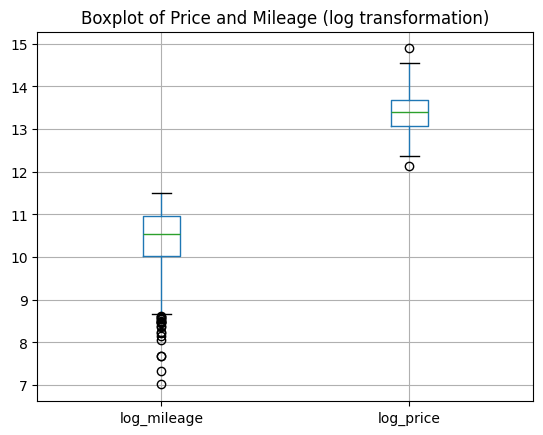

In [11]:
cars.boxplot(column=["log_mileage", "log_price"])
plt.title("Boxplot of Price and Mileage (log transformation)")
plt.show()

The price variable looks good, and although mileage has a bunch more outliers, they're still reasonable to keep because they're quite close toegether and not significantly far from the rest of the data (they represents low mileage cars).

##### 2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?

Summary of Price:

In [12]:
cars["Price"].describe()

count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64

The mean is greater than the median, indicating that the data is right-skewed, which we already found above.

Kde plot (also shown in q1):

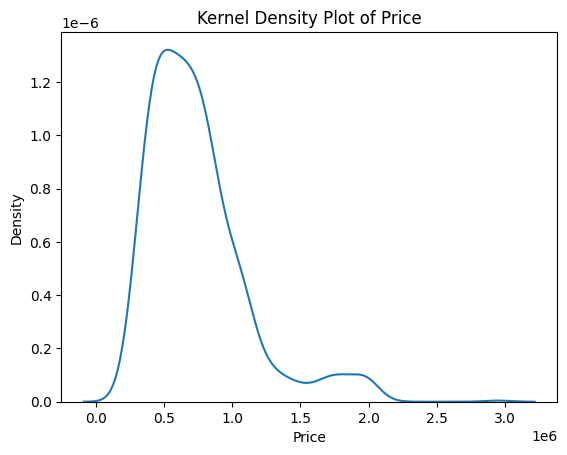

In [13]:
sns.kdeplot(cars, x = "Price")
plt.title("Kernel Density Plot of Price")
plt.show()

Summarizing prices by brand:

In [14]:
cars.groupby("Make")["Price"].describe().sort_values(by = "mean", ascending = False)

,count,mean,std,min,25%,50%,75%,max
Make,,,,,,,,
MG Motors,35.0,1.869457e+06,1.216611e+05,1589000.0,1786500.0,1848000.0,1978000.0,2019000.0
Kia,8.0,1.614750e+06,1.190567e+05,1369000.0,1579000.0,1628500.0,1705750.0,1741000.0
Jeep,4.0,1.499500e+06,1.525134e+05,1290000.0,1447500.0,1529500.0,1581500.0,1649000.0
Skoda,5.0,1.136000e+06,1.070175e+06,436000.0,466000.0,538000.0,1299000.0,2941000.0
Mahindra,18.0,1.100167e+06,1.755493e+05,796000.0,1037000.0,1094500.0,1157000.0,1465000.0
Tata,23.0,1.055217e+06,5.578305e+05,188000.0,779500.0,869000.0,1552000.0,2100000.0
Nissan,4.0,8.842500e+05,2.895599e+05,475000.0,782500.0,978000.0,1079750.0,1106000.0
Toyota,50.0,8.003400e+05,2.466900e+05,368000.0,526250.0,894000.0,1023000.0,1092000.0
Honda,73.0,7.989726e+05,2.665091e+05,316000.0,581000.0,785000.0,915000.0,1537000.0


The top 5 most expensive (by average price) car brands are:
- MG Motors
- Kia
- Jeep
- Skoda
- Mahindra

The least 5 expensive car brands are:
- Renault
- Volkswagen
- Maruti Suzuki
- Chevrolet
- Datsun

Now let's make a grouped kde plot showing each brand

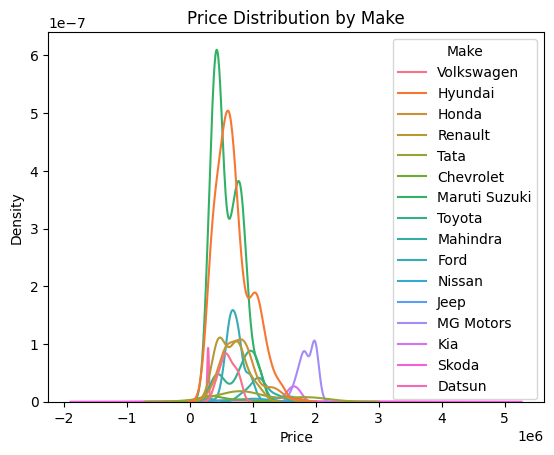

In [15]:
sns.kdeplot(cars, x="Price", hue="Make")
plt.title("Price Distribution by Make")
plt.show()

In general, the prices for the car brands look slightly right-skewed. It looks like Maruti Suzuki and Hyundai have prices that are more concentrated together, as indicated by their taller and skinny plots. It's also clear the MG Motors is more expensive since it's peak is located much more to the right than the other peaks from other brands. Overall, though, most of the car brands seem to have their peaks (the mode, or number of observations) between $200,000 and $1 million.

##### 3. Split the data into an 80% training set and a 20% testing set.

First we need to define our independent and dependent variables:

In [16]:
X = cars.drop(columns=["Price"])  # drop our target variable since it's what we want to predict
y = cars["Price"]                  

Then split into training and testing data:

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=83)

##### 4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?

**First model: numeric variables alone**

Defining the numeric columns:

In [29]:
numeric_cols = [
    "Make_Year",
    "log_mileage",
    "No_of_Owners",
    "Seating_Capacity"
]

Defining X and y, then partitioning the data:

In [30]:
# just numeric columns
X_num = cars[numeric_cols]
y = cars["log_price"]

# split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_num, y, test_size=0.2, random_state=83)

Fit model and make predictions:

In [31]:
# fit
model_num = LinearRegression().fit(X_train, y_train)

# predictions
y_train_pred = model_num.predict(X_train)
y_test_pred = model_num.predict(X_test)

Looking at the metrics:

In [32]:
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Numeric Model:")
print("Train R²:", r2_train)
print("Test R²:", r2_test)
print("Train RMSE:", rmse_train)
print("Test RMSE:", rmse_test)

Numeric Model:
Train R²: 0.4139365898792631
Test R²: 0.44535813300220106
Train RMSE: 0.3392053741716786
Test RMSE: 0.3543894130521419


**Second model: categorical variables alone**

Defining categorical columns:

In [33]:
categorical_cols = [
    "Make",
    "Color",
    "Body_Type",
    "Fuel_Type",
    "Transmission",
    "Transmission_Type"
]

Defining X (by one-hot encoding the categorical columns) then splitting:

In [34]:
X_cat = pd.get_dummies(
    cars[categorical_cols],
    drop_first=True   # to avoid dummy variable trap
)

# split - y is still price
X_train_c, X_test_c, y_train, y_test = train_test_split(X_cat, y, test_size=0.2, random_state=83)


Fitting and Predicting:

In [35]:
# fit
model_cat = LinearRegression().fit(X_train_c, y_train)

# predict
y_test_pred = model_cat.predict(X_test_c)

Metrics on test set:

In [36]:
r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Categorical Model:")
print("Test R²:", r2_test)
print("Test RMSE:", rmse_test)

Categorical Model:
Test R²: 0.638659686655032
Test RMSE: 0.28604385558802237


The categorical model performed significantly better on the test then compared to the numerical model, having a much higher $R^2$ of 0.639 and a lower RMSE at 0.286 (RMSE in log units now).

**Third Model: Combination of Previous Regressors**

Defining X (combining the numerical and categorical columns) and splitting:

In [51]:
X_all = pd.concat([X_num, X_cat], axis=1)

# split
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(X_all, y, test_size=0.2, random_state=83)

Fitting and predicting:

In [52]:
# fit
model_all = LinearRegression().fit(X_train_all, y_train_all)

# predict
y_test_pred = model_all.predict(X_test_all)

Metrics on test set:

In [53]:
r2_test = r2_score(y_test_all, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test_all, y_test_pred))

print("Combined Model:")
print("Test R²:", r2_test)
print("Test RMSE:", rmse_test)

Combined Model:
Test R²: 0.8237013489317915
Test RMSE: 0.19980157599310672


The joint model performs better than both the previous two models. It has an $R^2$ value of 0.824, which is almost 0.2 higher than the categorical model; and it has an RMSE of 0.1998, which is around 0.09 lower than the categorical model.

##### 5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?

We're using the same numeric cols from above ("Make_Year", "log_mileage", "No_of_Owners", "Seating_Capacity"):

In [45]:
# Define features and target
X = cars[numeric_cols]
y = cars["log_price"]   

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=83)

Now we'll loop through different degrees of expansion on the feature variables, creating a model for each degree and looking at its variance and RMSE:

In [46]:
# Looking at degrees 1 through 10
degrees = range(1, 11)   

# Initialize a results list that will contain degree, r^2, and RMSE:
results = []

for d in degrees:
    # Using PolynomialFeatures object
    pf = PolynomialFeatures(degree=d, include_bias=False)
    
    # Fit the transformation on data and apply it --
    # creating new polynomial features like x^2
    X_train_poly = pf.fit_transform(X_train)
    X_test_poly = pf.transform(X_test)
    
    # Fitting linear regression model using the expanded (polynomial) features
    model = LinearRegression().fit(X_train_poly, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    
    # R^2 on training and test data
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    
    # RMSE on test data 
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    # Store results
    results.append((d, r2_train, r2_test, rmse_test))
    
    # Print results for this degree
    print(f"Degree {d}: Train R²={r2_train:.4f}, Test R²={r2_test:.4f}, RMSE={rmse_test:.2f}")

Degree 1: Train R²=0.4139, Test R²=0.4454, RMSE=0.35
Degree 2: Train R²=0.4470, Test R²=0.4523, RMSE=0.35
Degree 3: Train R²=0.4549, Test R²=0.1953, RMSE=0.43
Degree 4: Train R²=0.4554, Test R²=0.3213, RMSE=0.39
Degree 5: Train R²=0.4554, Test R²=0.3222, RMSE=0.39
Degree 6: Train R²=0.4555, Test R²=0.3230, RMSE=0.39
Degree 7: Train R²=0.4555, Test R²=0.3238, RMSE=0.39
Degree 8: Train R²=0.4555, Test R²=0.3245, RMSE=0.39
Degree 9: Train R²=0.4556, Test R²=0.3252, RMSE=0.39
Degree 10: Train R²=0.4556, Test R²=0.3254, RMSE=0.39


- As the degree of expansion increases, the $R^2$ increases from degree 1 to degree 2, then drops significantly on degree 3, but then stabilizes around 0.32. The RMSE is lowest on the models with degree 1 and 2, and it's the biggest on the model with degree 3. Even as the degree increases after that, the RMSE drops lower and then doesn't change from degree 4 and on.
- The $R^2$ does not go negative.
- The best model with expanded features is of degree 2 with an $R^2$ of 0.4523 and an RMSE of 0.35. This is much worse than the joint model from question 4, which had an $R^2$ of 0.824 and an RMSE of 0.1998. This can be likely due to the fact that the polynomial model only used the numerical features while the joint model included both the numeric and categorical columns.


##### 6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

My best model the joint model that included both the numeric and categorical features from question 4 (not polynomial).

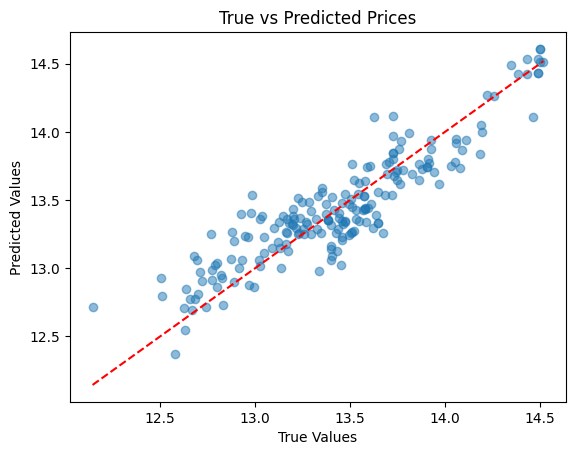

In [ ]:
# predictions on test set
y_pred = model_all.predict(X_test_all)

# scatter plot
plt.scatter(y_test_all, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')  # diagonal line

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Prices (log)")
plt.show()

It appears that predicted values and true values roughly line up along the diagonal.

Now let's define the residuals and make a kde plot:

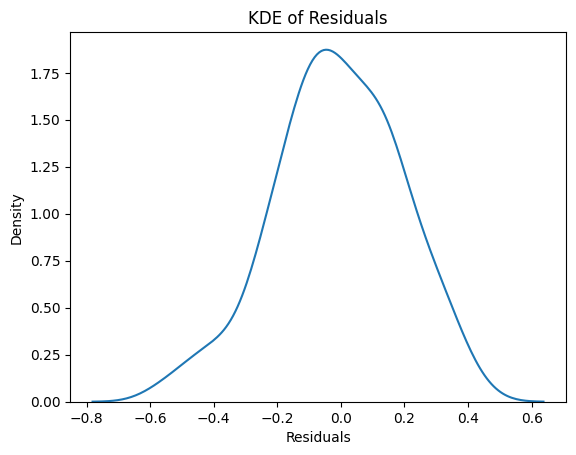

In [55]:
residuals = y_test_all - y_pred

sns.kdeplot(residuals)
plt.title("KDE of Residuals")
plt.xlabel("Residuals")
plt.show()

The residuals curve definitely looks bell-shaped around 0.

Finally, let's examine some strengths and weaknesses of this model.

Strengths:
- The model captures the underlying pattern in the data.
- The predicted values are pretty close to the true values (they're close to the diagonal)
- The residuals (the model error) are pretty much centered around 0
- The model uses both numeric and categorical features of the data

Weaknesses:
- The residual kde plot has a slight skew to it (not perfectly symmetrical)
- The $R^2$ isn't incredibly high, meaning the model can still be better at capturing variance in the data.
- There are a few points on the true vs predicted price scatterplot that are decently far from the diagonal (model was far off)